# [03 Monitoring — baseline model + drift & performance]

Phase 1 deliverable: a systematic, repeatable post-deployment monitoring setup. We:
1. Train a **simple baseline** model (no tuning — real experiment tracking is Phase 2).
2. Treat each **month as a simulated production batch** and compare it to the training reference.
3. Generate **Evidently data-drift reports** per month → `monitoring/reports/`.
4. Track **model performance (MAE/RMSE) per month** to watch for degradation.

This notebook **imports the transform from `src/los_pred/features.py`** (single source of truth) rather than redefining it — the same code that made the splits and that Phase 3's API will serve.

Deps (install hands-on): `uv add evidently scikit-learn`

## 0. Setup — load raw, rebuild features from `src/`

We re-derive from the raw CSV using the `src` functions (reproducible, and needed so we can transform each monthly batch with the **train-fitted** params). 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from los_pred import features
from los_pred.features import add_batch_month, temporal_split, fit_transformer, transform, TARGET

CUTOFF = pd.Period("2012-10", freq="M")

df = add_batch_month(pd.read_csv("../data/LengthOfStay.csv"))
train_df, test_df = temporal_split(df, cutoff=str(CUTOFF))

# Fit the transform on TRAIN only, then build feature matrices.
params = fit_transformer(train_df)
X_train, y_train = transform(train_df, params), train_df[TARGET]
X_all, y_all = transform(df, params), df[TARGET]   # every row, for per-month scoring
print(f"train {X_train.shape}   all {X_all.shape}")


train (83047, 28)   all (100000, 28)


## 1. Baseline model

A single, untuned `HistGradientBoostingRegressor` — enough to produce predictions to monitor. Predictions are floor-clipped at 1 (per the 01_eda §8 decision). Compare against the naive baseline **MAE = 1.914**.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor


model = LGBMRegressor(random_state=0)

#model = HistGradientBoostingRegressor(random_state=0)
model.fit(X_train, y_train)

X_test, y_test = transform(test_df, params), test_df[TARGET]
pred_test = np.clip(model.predict(X_test), 1, None)
mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print(f"test MAE={mae:.3f}  RMSE={rmse:.3f}   (naive baseline MAE=1.914)")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1720
[LightGBM] [Info] Number of data points in the train set: 83047, number of used features: 27
[LightGBM] [Info] Start training from score 4.001854
test MAE=0.371  RMSE=0.532   (naive baseline MAE=1.914)


## 2. Evidently data-drift reports (per month)

**Reference** = the training feature distribution. **Current** = each later month (simulated production batch). Evidently compares them and flags which features drifted.

> Uses Evidently's current API (`Dataset` / `DataDefinition` / `Report` + `DataDriftPreset`). If your installed version differs, check the [quickstart](https://docs.evidentlyai.com/quickstart_ml).

In [8]:
from evidently import Dataset, DataDefinition, Report
from evidently.presets import DataDriftPreset

# Binary flags / one-hot -> categorical; continuous labs/vitals/counts -> numerical.
cat_cols = [c for c in X_train.columns if c.startswith("fac_") or c in features.FLAGS or c == "isMale"]
num_cols = [c for c in X_train.columns if c not in cat_cols]
schema = DataDefinition(numerical_columns=num_cols, categorical_columns=cat_cols)

reference_ds = Dataset.from_pandas(X_train, data_definition=schema)
current_months = [m for m in sorted(df["batch_month"].unique()) if m > CUTOFF]
print("current (production) months:", [str(m) for m in current_months])

current (production) months: ['2012-11', '2012-12']


In [9]:
from pathlib import Path

reports_dir = Path("../monitoring/reports")
reports_dir.mkdir(parents=True, exist_ok=True)

for m in current_months:
    current = X_all[df["batch_month"] == m]
    current_ds = Dataset.from_pandas(current, data_definition=schema)

    report = Report([DataDriftPreset()])
    snapshot = report.run(current_ds, reference_ds)   # (current, reference)
    out = reports_dir / f"drift_{m}.html"
    snapshot.save_html(str(out))
    print("saved", out.name)

saved drift_2012-11.html
saved drift_2012-12.html


## 3. Model performance over months

Score the baseline on every monthly batch and watch MAE/RMSE. Training months are **in-sample** (optimistic) — the honest signal is whether the **test months** degrade vs the training months.

In [10]:
pred_all = pd.Series(np.clip(model.predict(X_all), 1, None), index=X_all.index)

rows = []
for m in sorted(df["batch_month"].unique()):
    mask = df["batch_month"] == m
    rows.append({
        "month": str(m),
        "n": int(mask.sum()),
        "mae": mean_absolute_error(y_all[mask], pred_all[mask]),
        "rmse": np.sqrt(mean_squared_error(y_all[mask], pred_all[mask])),
        "split": "train" if m <= CUTOFF else "test",
    })
perf = pd.DataFrame(rows)
perf

,month,n,mae,rmse,split
0,2012-01,8337,0.362116,0.512892,train
1,2012-02,8011,0.359376,0.507970,train
2,2012-03,8442,0.363812,0.509173,train
3,2012-04,7940,0.349093,0.494968,train
4,2012-05,8482,0.360254,0.509630,train
5,2012-06,8226,0.355123,0.501990,train
6,2012-07,8323,0.358819,0.508418,train
7,2012-08,8478,0.354438,0.505703,train
8,2012-09,8242,0.356408,0.508876,train
9,2012-10,8566,0.353126,0.501894,train


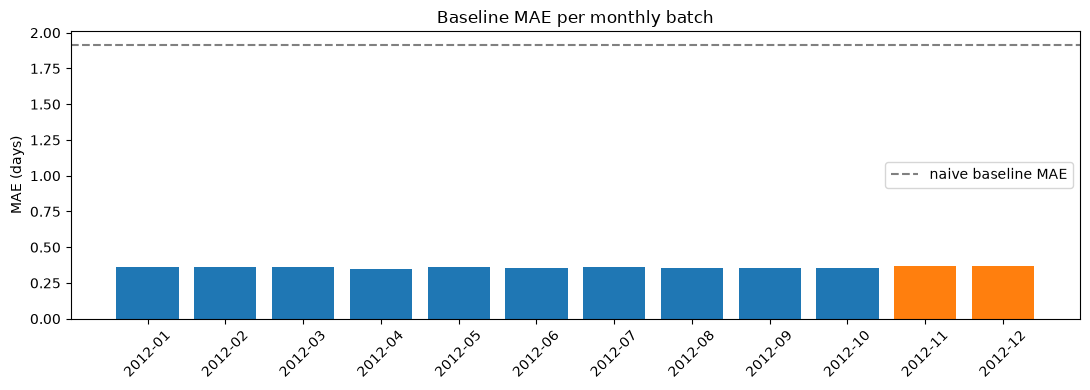

In [11]:
colors = perf["split"].map({"train": "tab:blue", "test": "tab:orange"})
plt.figure(figsize=(11, 4))
plt.bar(perf["month"], perf["mae"], color=colors)
plt.axhline(1.914, ls="--", c="grey", label="naive baseline MAE")
plt.ylabel("MAE (days)"); plt.xticks(rotation=45); plt.legend(); plt.title("Baseline MAE per monthly batch")
plt.tight_layout();

### _Optional: Evidently regression performance report per month (Evidently 0.7.x API)_

By adding a `prediction` column to a dataset and using Evidently's regression preset (`from evidently.presets import RegressionPreset`) with a `DataDefinition` that declares the target/prediction.


In [14]:
# Reuses the actuals (y_all) and predictions (pred_all) computed above.
# Reference = training months; current = each later month. RegressionPreset gives
# MAE/RMSE/ME, error distribution, and predicted-vs-actual — a richer HTML than the
# plain metrics table in section 3.
from evidently import Regression
from evidently.presets import RegressionPreset

reg_def = DataDefinition(
    regression=[Regression(target=TARGET, prediction="prediction")]
)


def _perf_ds(mask):
    frame = pd.DataFrame({TARGET: y_all[mask].values, "prediction": pred_all[mask].values})
    return Dataset.from_pandas(frame, data_definition=reg_def)


ref_perf = _perf_ds(df["batch_month"] <= CUTOFF)          # training reference
for m in current_months:
    cur_perf = _perf_ds(df["batch_month"] == m)
    report = Report([RegressionPreset()])
    snapshot = report.run(cur_perf, ref_perf)             # (current, reference)
    out = reports_dir / f"performance_{m}.html"
    snapshot.save_html(str(out))
    print("saved", out.name)


saved performance_2012-11.html
saved performance_2012-12.html


## 4 · Findings / reflection

_Per the plan's Phase-1 tasks:_

Table summary on model performance       
train months:  MAE ~0.349–0.364      
test  (Nov):   MAE 0.370       
test  (Dec):   MAE 0.372      
naive baseline MAE 1.914         


- **Which features drift, and when?** (from the Evidently reports)     
    Checking the drift score and comparing the graphs between the current and reference distributions, no features appear to drift (most likely because this is a just simulated data-set, no consideration about simulating gradual drift was taken into consideration when it was created)


- **Does performance degrade on later months?** (from §3)      
    Again no considerable differences between reference and curent months. 

- Two things worth making explicit:    
    i. MAE 0.37 days on a target with mean 4 / std 2.36 → R² ≈ 0.95. That's near-perfect. The model is suspiciously good.    
    >> First reflex when metrics look too good = check for leakage. We were careful (dropped vdate/discharged/eid), and the remaining features are all known-at-admission, so there's no leak here. But always good to form the habit of asking is the point — "0.37 MAE, is that real or am I cheating?

    ii. Compared to simple linear regression, LightGBM combines weakly-linear features into a near-perfect nonlinear fit. This synthetic dataset is near-deterministic, so both drift and error are minimal — which limits it as a monitoring demo but is a valid, explainable outcome.


- **Reflection (plan task):** what would a drift report have looked like on time-series telematics data (speed, acceleration)? What would have triggered an alert?    


    On telematics (speed, acceleration), a drift report would compare a recent window against a reference period. An alert would fire when a feature's distribution distance (PSI/KS/Wasserstein) crosses a threshold — e.g. a seasonal drop in average speed, or a sensor recalibration shifting the acceleration distribution — or when the share of drifting features exceeds a dataset-level limit.     
    
    The subtler risk is concept drift: the same speed/acceleration mapping to different risk, which input-drift checks alone won't catch — you'd need performance monitoring against ground-truth labels.

## 5. Additional notes

**Jensen–Shannon distance**       
 
Used for categorical features (your flags, fac_*, isMale).       

A symmetric, bounded [0, 1] measure of how different two probability distributions are: 0 = identical, 1 = maximally different.       
Built from KL divergence but made symmetric and always finite, so it behaves like a proper distance (KL alone is neither).       
Compares category proportions — e.g. did the share of asthma cases shift between months?       


**Wasserstein distance (normed)**      

Used for numerical features (labs, vitals, counts).     

"Earth-mover's distance": the minimum work to reshape one distribution into the other — equivalently, the area between their cumulative curves. Unlike JS, it accounts for how far values move, not just whether the bins differ.        
Normed = divided by the reference's standard deviation → scale-free, so one threshold (≈ 0.1) is comparable across features with different units (glucose in mg/dL vs pulse in bpm).         
Sensitive to shifts in where a numeric feature sits — e.g. average glucose creeping up month over month.

#### **It's not sufficient to just monitor feature drift**     

Because of label delay. You only know the true LOS after the patient is discharged — so performance metrics (MAE/RMSE) are a lagging indicator; you can't compute them on fresh admissions yet. Feature drift, by contrast, is computable immediately from the inputs — a leading indicator. So the monitoring logic is:       

Feature drift fires early → "inputs are shifting, performance might be at risk — investigate."           
Performance monitoring confirms later (once labels arrive) → "did it actually degrade?"         

That's why a mature setup runs both, and why Phase 1 builds both drift and performance reports rather than just one.       

    

**_One-line takeaway_**     

Feature drift degrades performance only when it moves an important feature into regions the model handles poorly, or when the feature→target relationship itself changes — otherwise it's a flag to investigate, not proof of harm. That gap between "drift detected" and "performance dropped" is exactly why you monitor the two separately.